In [14]:
def parse_clinvar_xml(filepath):
    tree = ET.parse(filepath)
    root = tree.getroot()
    records = []
    for cv_record in root.iter('VariationArchive'):
        name = cv_record.get('VariationName', 'N/A')
        var_id = cv_record.get('VariationID', 'N/A')
        
        # Get all Description tags and take the last one (aggregate classification)
        descriptions = [e.text for e in cv_record.iter('Description') if e.text]
        significance = descriptions[-1] if descriptions else 'Unknown'
        
        records.append({
            'variation_id': var_id,
            'name': name,
            'clinical_significance': significance,
        })
    return pd.DataFrame(records)

In [15]:
pcsk9_variants = parse_clinvar_xml('../data/raw/clinvar_pcsk9.xml')
ldlr_variants  = parse_clinvar_xml('../data/raw/clinvar_ldlr.xml')
apob_variants  = parse_clinvar_xml('../data/raw/clinvar_apob.xml')

print(f'PCSK9 total: {len(pcsk9_variants)}')
print(f'LDLR total:  {len(ldlr_variants)}')
print(f'APOB total:  {len(apob_variants)}')

PCSK9 total: 500
LDLR total:  500
APOB total:  500


In [16]:
def filter_pathogenic(df):
    mask = df['clinical_significance'].str.contains(
        'Pathogenic|Likely pathogenic', case=False, na=False
    ) & ~df['clinical_significance'].str.contains(
        'Conflicting', case=False, na=False
    )
    return df[mask].reset_index(drop=True)

In [17]:
pcsk9_path = filter_pathogenic(pcsk9_variants)
ldlr_path  = filter_pathogenic(ldlr_variants)
apob_path  = filter_pathogenic(apob_variants)

print(f'Pathogenic PCSK9: {len(pcsk9_path)}')
print(f'Pathogenic LDLR:  {len(ldlr_path)}')
print(f'Pathogenic APOB:  {len(apob_path)}')

Pathogenic PCSK9: 5
Pathogenic LDLR:  198
Pathogenic APOB:  37


In [19]:
pcsk9_path.to_csv('../data/processed/pcsk9_pathogenic_variants.csv', index=False)
ldlr_path.to_csv('../data/processed/ldlr_pathogenic_variants.csv', index=False)
apob_path.to_csv('../data/processed/apob_pathogenic_variants.csv', index=False)

print('All pathogenic variant tables saved.')

All pathogenic variant tables saved.


In [21]:
from Bio import Entrez, SeqIO
import time

Entrez.email = 'your@email.com'

# Known PCSK9 GOF variants with NCBI protein accessions
key_variants = {
    'D374Y': 'Q8NBP7',        # GOF variant, most studied FH-associated
    'S127R': None,
    'F216L': None,
    'wild_type': 'NP_777596'  # Reference sequence
}

sequences = {}
for name, accession in key_variants.items():
    if accession:
        handle = Entrez.efetch(db='protein', id=accession, rettype='fasta', retmode='text')
        sequences[name] = handle.read()
        handle.close()
        time.sleep(1)

# Write multi-FASTA for alignment input
with open('../data/processed/pcsk9_variants_for_alignment.fasta', 'w') as f:
    for name, seq in sequences.items():
        lines = seq.strip().split('\n')
        f.write(f'>pcsk9_{name}\n')
        f.write('\n'.join(lines[1:]) + '\n')
print('Alignment input FASTA written.')


Alignment input FASTA written.


In [23]:
from Bio import SeqIO
from Bio.Align import PairwiseAligner

sequences = list(SeqIO.parse('../data/processed/pcsk9_variants_for_alignment.fasta', 'fasta'))

aligner = PairwiseAligner()
aligner.mode = 'global'

reference = sequences[0]
for seq in sequences[1:]:
    score = aligner.score(str(reference.seq), str(seq.seq))
    print(f'{reference.id} vs {seq.id}: alignment score = {score}')

pcsk9_D374Y vs pcsk9_wild_type: alignment score = 692.0


In [25]:
import requests, json

url = 'https://rest.uniprot.org/uniprotkb/Q8NBP7?format=json'
r = requests.get(url)
uniprot_data = r.json()

# Extract domain feature annotations
features = uniprot_data.get('features', [])
domains = [f for f in features if f['type'] in ['Domain', 'Region', 'Active site', 'Binding site']]

domain_df = pd.DataFrame([{
    'type': d['type'],
    'description': d.get('description', 'N/A'),
    'start': d['location']['start']['value'],
    'end': d['location']['end']['value']
} for d in domains])

domain_df.to_csv('../data/processed/pcsk9_domains.csv', index=False)
print(domain_df)

          type          description  start  end
0       Domain         Inhibitor I9     77  149
1       Domain         Peptidase S8    155  461
2       Region    C-terminal domain    450  692
3  Active site  Charge relay system    186  186
4  Active site  Charge relay system    226  226
5  Active site  Charge relay system    386  386


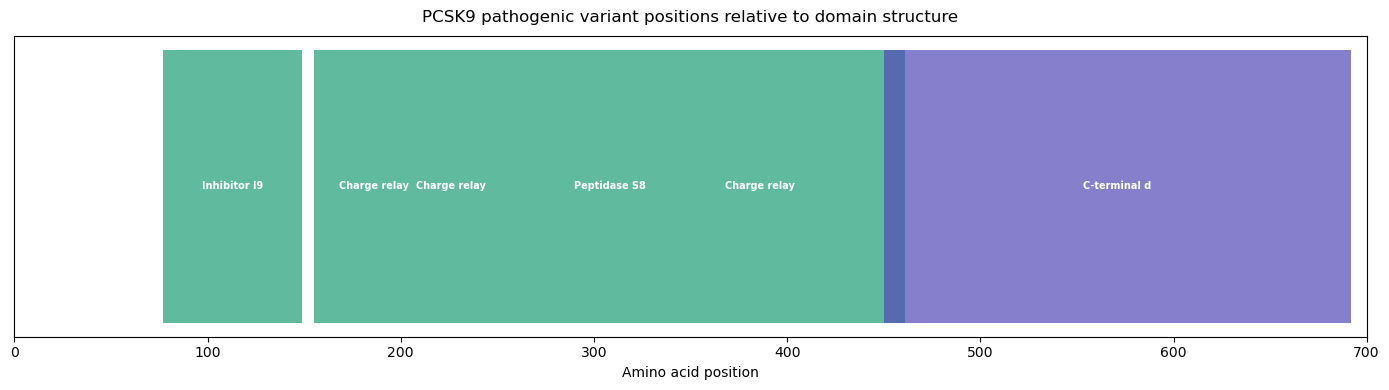

In [26]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import re

fig, ax = plt.subplots(figsize=(14, 4))

# Draw domain bars
colors = {'Domain': '#1D9E75', 'Region': '#534AB7', 'Active site': '#BA7517', 'Binding site': '#993C1D'}
for _, row in domain_df.iterrows():
    color = colors.get(row['type'], '#888780')
    ax.barh(0.5, row['end'] - row['start'], left=row['start'], height=0.3,
            color=color, alpha=0.7, label=row['description'])
    ax.text((row['start'] + row['end']) / 2, 0.5, row['description'][:12],
            ha='center', va='center', fontsize=7, color='white', fontweight='bold')

# Plot variant positions from your PCSK9 pathogenic variant table
def extract_position(name):
    match = re.search(r'p\.[A-Za-z]+([0-9]+)', name)
    return int(match.group(1)) if match else None

pcsk9_path['position_aa'] = pcsk9_path['name'].apply(extract_position)
positions = pcsk9_path['position_aa'].dropna()

ax.scatter(positions, [0.85] * len(positions), color='#E24B4A', s=30, zorder=5, alpha=0.7)

ax.set_xlabel('Amino acid position')
ax.set_title('PCSK9 pathogenic variant positions relative to domain structure', pad=10)
ax.set_yticks([])
ax.set_xlim(0, 700)
plt.tight_layout()
plt.savefig('../results/pcsk9_variant_domain_map.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
print(pcsk9_path['name'].head(10).tolist())

['NM_174936.4(PCSK9):c.399+1G>A', 'GRCh37/hg19 1p34.1-22.2(chr1:44475302-89585894)x3', 'NC_000001.10:g.(?_55464860)_(55505737_?)del', 'GRCh37/hg19 1p33-32.2(chr1:47493178-57042671)x3', 'Single allele']


In [28]:
import re

def extract_position(name):
    match = re.search(r'p\.[A-Za-z]{3}(\d+)', name)
    return int(match.group(1)) if match else None

# Filter to only variants that actually have protein-level notation
pcsk9_path_protein = pcsk9_path[pcsk9_path['name'].str.contains(r'p\.', na=False)].copy()
pcsk9_path_protein['position_aa'] = pcsk9_path_protein['name'].apply(extract_position)

print(f'{len(pcsk9_path_protein)} of {len(pcsk9_path)} pathogenic variants have protein-level positions')
print(pcsk9_path_protein[['name', 'position_aa']])

0 of 5 pathogenic variants have protein-level positions
Empty DataFrame
Columns: [name, position_aa]
Index: []


In [29]:
ldlr_path_protein = ldlr_path[ldlr_path['name'].str.contains(r'p\.', na=False)].copy()
ldlr_path_protein['position_aa'] = ldlr_path_protein['name'].apply(extract_position)
print(f'{len(ldlr_path_protein)} of {len(ldlr_path)} LDLR pathogenic variants have protein-level positions')

146 of 198 LDLR pathogenic variants have protein-level positions


In [34]:
ldlr_features_filtered = [f for f in ldlr_features if f['type'] in 
    ['Domain', 'Region', 'Repeat', 'Topological domain', 'Transmembrane']]

ldlr_domain_df = pd.DataFrame([{
    'type': f['type'],
    'description': f.get('description', 'N/A'),
    'start': f['location']['start']['value'],
    'end': f['location']['end']['value']
} for f in ldlr_features_filtered])

print(ldlr_domain_df)

                  type                                        description  \
0   Topological domain                                      Extracellular   
1        Transmembrane                                            Helical   
2   Topological domain                                        Cytoplasmic   
3               Domain                             LDL-receptor class A 1   
4               Domain                             LDL-receptor class A 2   
5               Domain                             LDL-receptor class A 3   
6               Domain                             LDL-receptor class A 4   
7               Domain                             LDL-receptor class A 5   
8               Domain                             LDL-receptor class A 6   
9               Domain                             LDL-receptor class A 7   
10              Domain                                         EGF-like 1   
11              Domain                        EGF-like 2; calcium-binding   

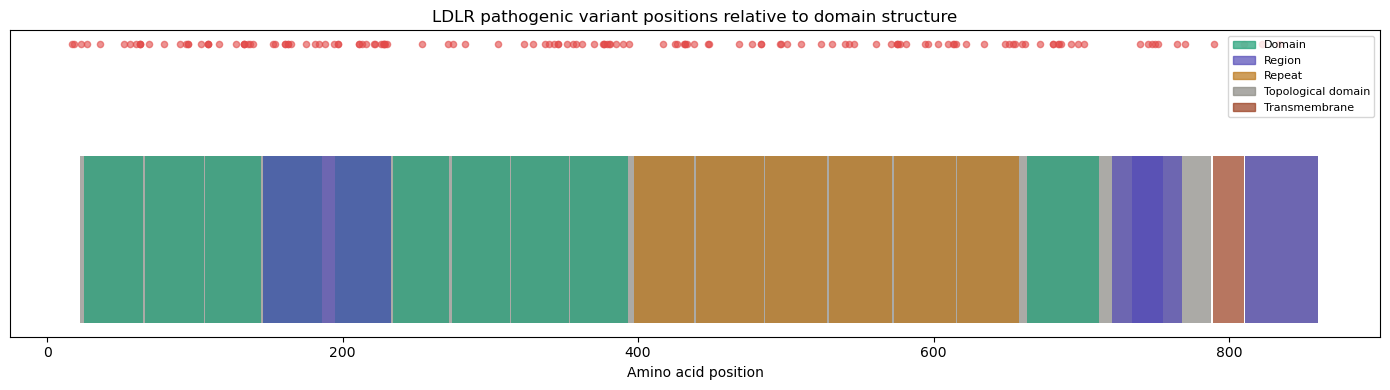

In [36]:
fig, ax = plt.subplots(figsize=(14, 4))

colors = {'Domain': '#1D9E75', 'Region': '#534AB7', 'Repeat': '#BA7517', 
          'Topological domain': '#888780', 'Transmembrane': '#993C1D'}
for _, row in ldlr_domain_df.iterrows():
    color = colors.get(row['type'], '#888780')
    ax.barh(0.5, row['end'] - row['start'], left=row['start'], height=0.3,
            color=color, alpha=0.7)

positions = ldlr_path_protein['position_aa'].dropna()
ax.scatter(positions, [0.85] * len(positions), color='#E24B4A', s=20, zorder=5, alpha=0.6)

ax.set_xlabel('Amino acid position')
ax.set_title('LDLR pathogenic variant positions relative to domain structure')
ax.set_yticks([])
plt.tight_layout()
plt.savefig('../results/ldlr_variant_domain_map.png', dpi=150, bbox_inches='tight')
import matplotlib.patches as mpatches

legend_patches = [mpatches.Patch(color=color, label=dtype, alpha=0.7) 
                   for dtype, color in colors.items()]
ax.legend(handles=legend_patches, loc='upper right', fontsize=8)
plt.savefig('../results/ldlr_variant_domain_map.png', dpi=150, bbox_inches='tight')
plt.show()

In [32]:
pcsk9_known_variants = pd.DataFrame([
    {'variant': 'S127R', 'position_aa': 127, 'effect': 'GOF', 'domain': 'Prodomain'},
    {'variant': 'F216L', 'position_aa': 216, 'effect': 'GOF', 'domain': 'Catalytic'},
    {'variant': 'D374Y', 'position_aa': 374, 'effect': 'GOF', 'domain': 'Catalytic'},
    {'variant': 'R218S', 'position_aa': 218, 'effect': 'GOF', 'domain': 'Catalytic'},
])
pcsk9_known_variants.to_csv('../data/processed/pcsk9_known_gof_variants.csv', index=False)
print(pcsk9_known_variants)

  variant  position_aa effect     domain
0   S127R          127    GOF  Prodomain
1   F216L          216    GOF  Catalytic
2   D374Y          374    GOF  Catalytic
3   R218S          218    GOF  Catalytic


In [11]:
import xml.etree.ElementTree as ET

tree = ET.parse('../data/raw/clinvar_pcsk9.xml')
root = tree.getroot()

# Look at the first VariationArchive in detail
first = root[0]
print('VariationName:', first.get('VariationName'))
print()

# Print all tags nested inside to find where clinical significance lives
for elem in first.iter():
    if 'significance' in elem.tag.lower() or 'interpretation' in elem.tag.lower() or 'description' in elem.tag.lower():
        print(f'Tag: {elem.tag}, Text: {elem.text}, Attrib: {elem.attrib}')

VariationName: NM_174936.4(PCSK9):c.1518G>T (p.Lys506Asn)

Tag: Description, Text: Uncertain significance, Attrib: {'DateLastEvaluated': '2024-04-29', 'SubmissionCount': '1'}
Tag: Description, Text: Uncertain significance, Attrib: {}
Tag: SubmitterDescription, Text: None, Attrib: {'OrgID': '508197', 'SubmitterName': 'Shariant Australia, Australian Genomics', 'Type': 'behalf', 'OrganizationCategory': 'consortium'}


In [12]:
import xml.etree.ElementTree as ET

tree = ET.parse('../data/raw/clinvar_pcsk9.xml')
root = tree.getroot()

# Find all Description texts and count them
from collections import Counter
descriptions = []
for elem in root.iter('Description'):
    if elem.text:
        descriptions.append(elem.text)

counts = Counter(descriptions)
for significance, count in counts.most_common():
    print(f'{significance}: {count}')

Uncertain significance: 729
Likely benign: 396
Conflicting classifications of pathogenicity: 20
Likely pathogenic: 6
Benign: 4
Pathogenic: 4
Benign/Likely benign: 1


In [37]:
import os
print(os.listdir('../results'))

['ldlr_variant_domain_map.png', 'pcsk9_variant_domain_map.png']
